### Load Data

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def generate_data(n, r, inv=False):
    x = list(range(-n//2, n//2))
    if inv:
        y = [n-random.randint(i-r, i+r) for i in x]
    else:
        y = [random.randint(i-r, i+r) for i in x]
    plt.scatter(x, y)
    plt.grid()
    plt.show()
    return np.array(x), np.array(y)

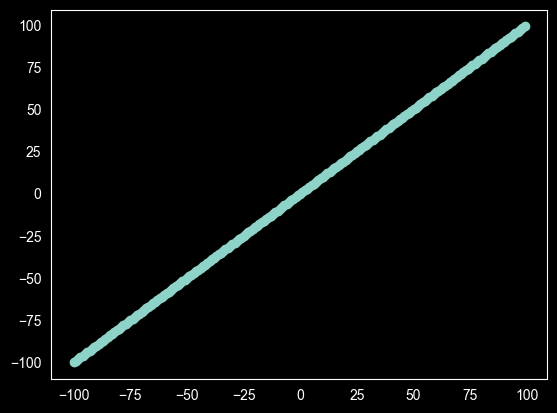

In [2]:
# Data 1
n = 200
r = 0
x1, y1 = generate_data(n, r)

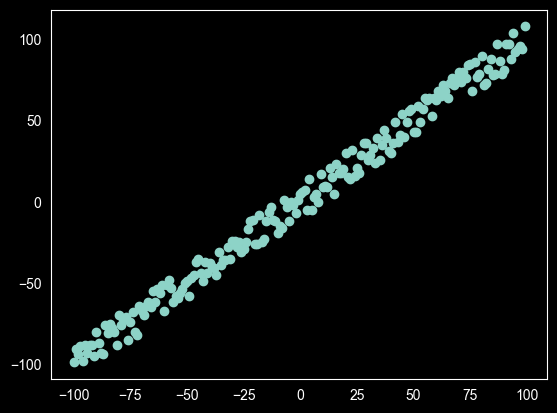

In [3]:
# Data 2
n = 200
r = 10
x2, y2 = generate_data(n, r)

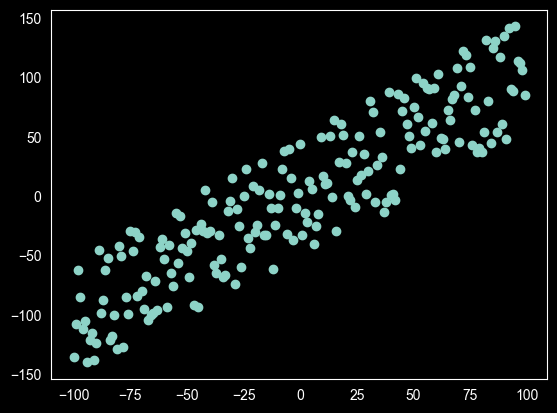

In [4]:
# Data 3
n = 200
r = 50
x3, y3 = generate_data(n, r)

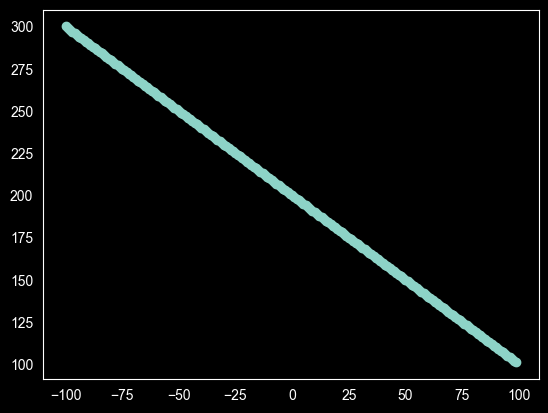

In [5]:
# Data 4
n = 200
r = 0
x4, y4 = generate_data(n, r, inv=True)

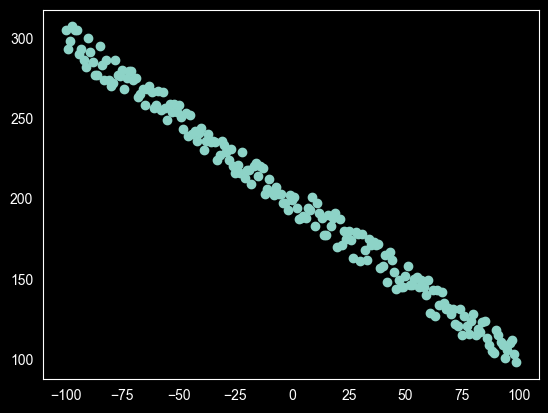

In [6]:
# Data 5
n = 200
r = 10
x5, y5 = generate_data(n, r, inv=True)

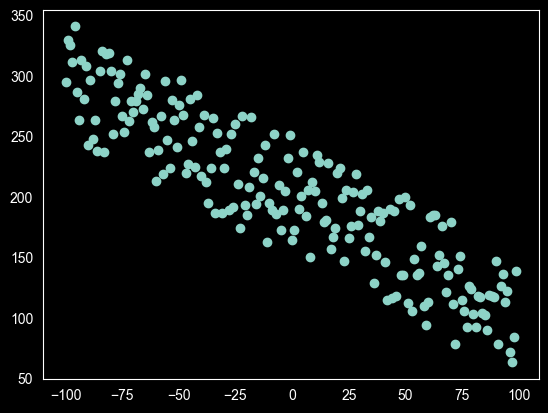

In [7]:
# Data 6
n = 200
r = 50
x6, y6 = generate_data(n, r, inv=True)

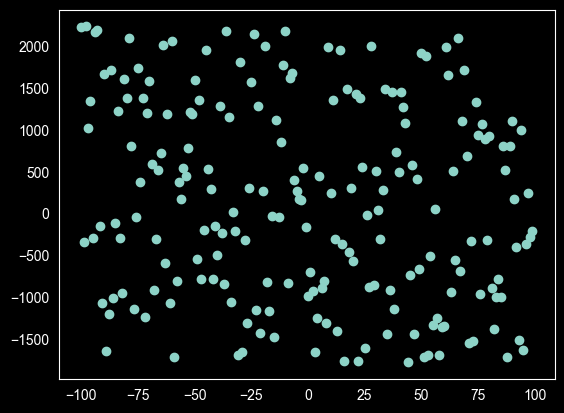

In [8]:
# Data 7
n = 200
r = 2000
x7, y7 = generate_data(n, r, inv=True)

### Utils

In [9]:
def predict(x, m, c):
    return m*x + c

In [10]:
def mse(y, y_pred):
    n = len(y)
    sse = 0
    error = y_pred - y
    se = error**2
    sse = sum(se)
    mse = sse/n
    return round(mse, 4)

In [11]:
def r2(y, y_pred):
    y_mean = np.mean(y)
    return round(1 - sum((y-y_pred)**2)/sum((y-y_mean)**2), 4)

In [12]:
def plot(x, y, m, c):
    plt.scatter(x, y)
    plt.plot(x, [m*i+c for i in x], "r")
    plt.grid()
    plt.show()

### Solve by Normal Equation

In [13]:
def solve_by_norm_eq(x, y, lmbda=300000):
    x_b = np.array([[1, i] for i in x])
    I = np.eye(2)
    I[0, 0] = 0
    c, m = np.linalg.inv(x_b.T @ x_b + lmbda * I) @ x_b.T @ y
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)

Slope : 0.6896   y-Intercept : -0.1552   MSE : 321.0494   R2 : 0.9037


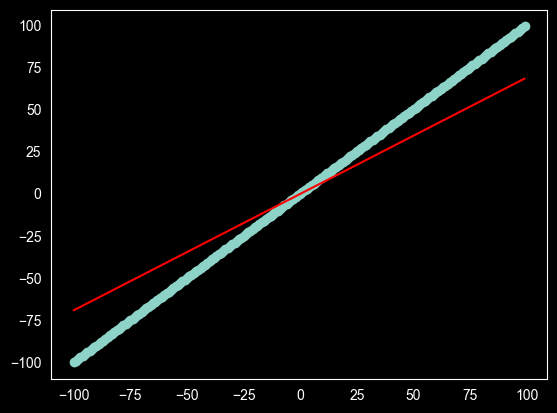

In [14]:
# Solve for Data 1
solve_by_norm_eq(x1, y1)

Slope : 0.6861   y-Intercept : 0.908   MSE : 355.7869   R2 : 0.8934


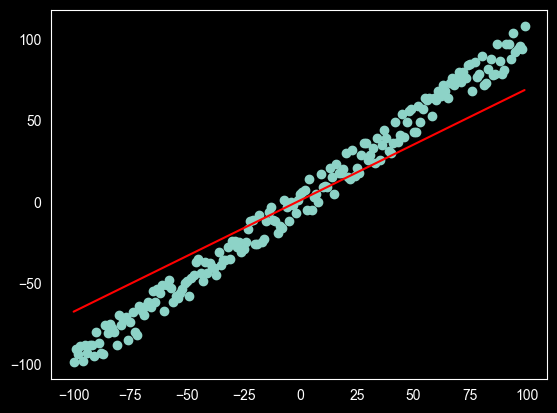

In [15]:
# Solve for Data 2
solve_by_norm_eq(x2, y2)

Slope : 0.7348   y-Intercept : 1.0874   MSE : 1210.0721   R2 : 0.7386


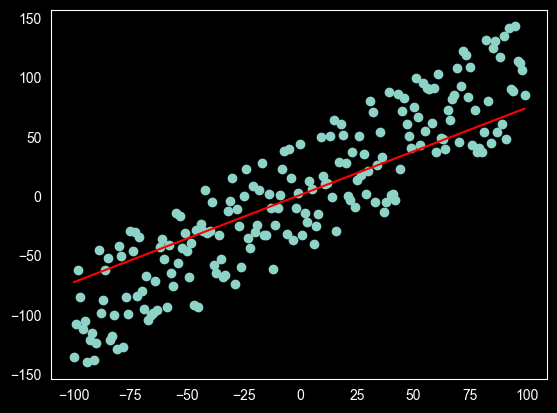

In [16]:
# Solve for Data 3
solve_by_norm_eq(x3, y3)

Slope : -0.6896   y-Intercept : 200.1552   MSE : 321.0494   R2 : 0.9037


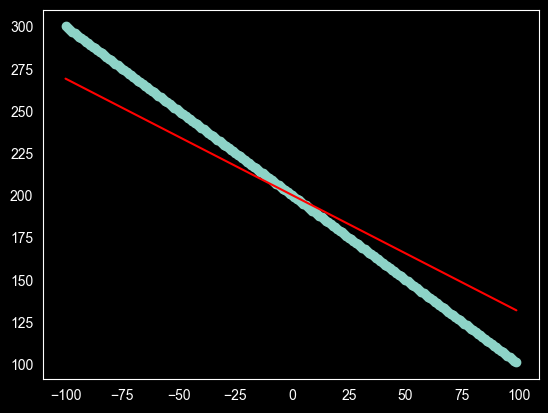

In [17]:
# Solve for Data 4
solve_by_norm_eq(x4, y4)

Slope : -0.6864   y-Intercept : 200.2118   MSE : 353.4238   R2 : 0.8941


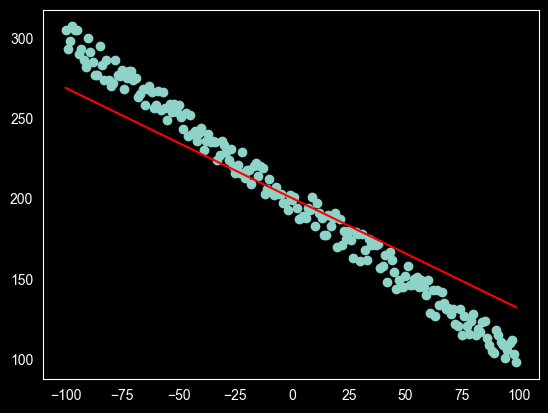

In [18]:
# Solve for Data 5
solve_by_norm_eq(x5, y5)

Slope : -0.6902   y-Intercept : 202.3649   MSE : 1094.1962   R2 : 0.7338


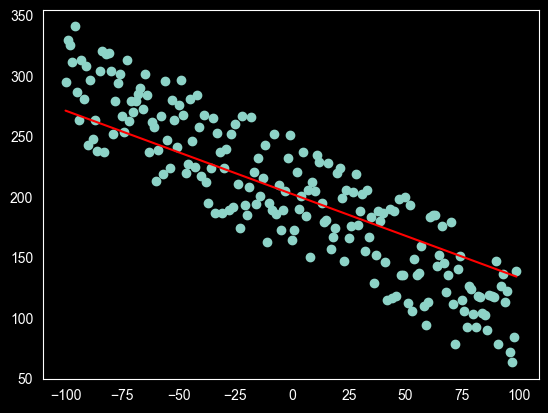

In [19]:
# Solve for Data 6
solve_by_norm_eq(x6, y6)

Slope : -2.7365   y-Intercept : 142.5768   MSE : 1344316.4125   R2 : 0.0341


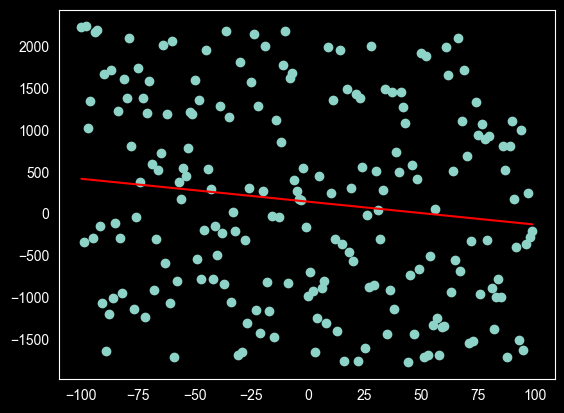

In [20]:
# Solve for Data 7
solve_by_norm_eq(x7, y7)

### Solve by SVD

In [21]:
def solve_by_svd(x, y, alpha=100000):
    X = np.array([[1, i] for i in x])
    R = np.array([[0, 0], [0, 1]])
    A = X.T @ X + alpha * R
    b = X.T @ y
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    S_inv = np.diag(1 / S)
    theta = Vt.T @ S_inv @ U.T @ b
    c, m = theta[0], theta[1]
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(f"Slope :", round(m, 8),
        "  y-Intercept :", round(c, 8),
        "  MSE :", MSE,
        "  R2 :", R2)
    plot(x, y, m, c)

Slope : 0.86956238   y-Intercept : -0.06521881   MSE : 56.7118   R2 : 0.983


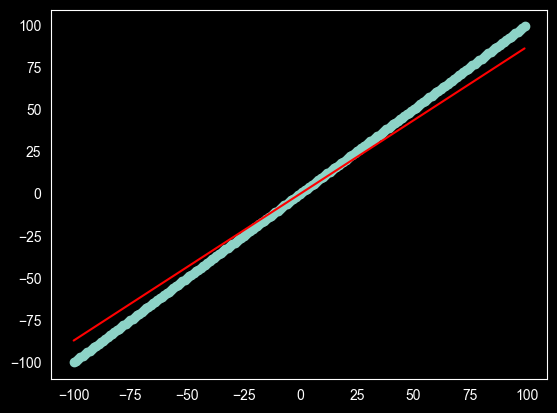

In [22]:
# Solve for Data 1
solve_by_svd(x1, y1)

Slope : 0.86503685   y-Intercept : 0.99751842   MSE : 94.1936   R2 : 0.9718


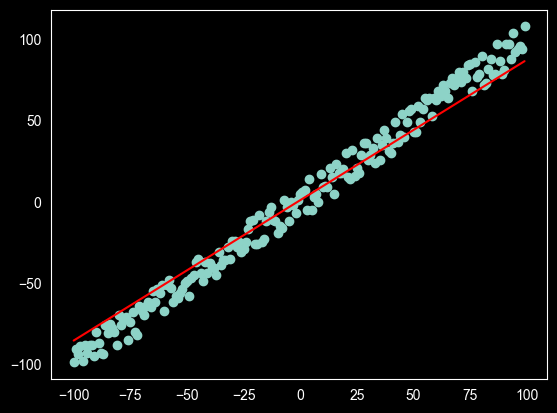

In [23]:
# Solve for Data 2
solve_by_svd(x2, y2)

Slope : 0.9264371   y-Intercept : 1.18321855   MSE : 910.0251   R2 : 0.8034


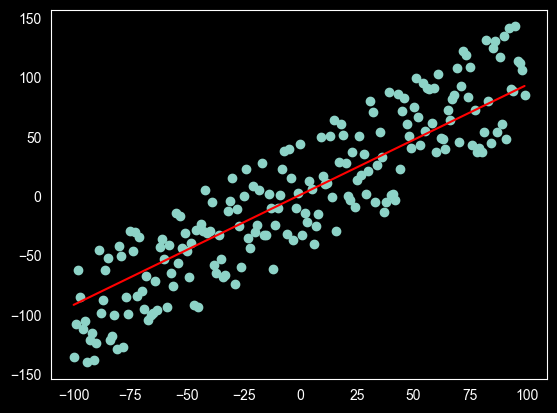

In [24]:
# Solve for Data 3
solve_by_svd(x3, y3)

Slope : -0.86956238   y-Intercept : 200.06521881   MSE : 56.7118   R2 : 0.983


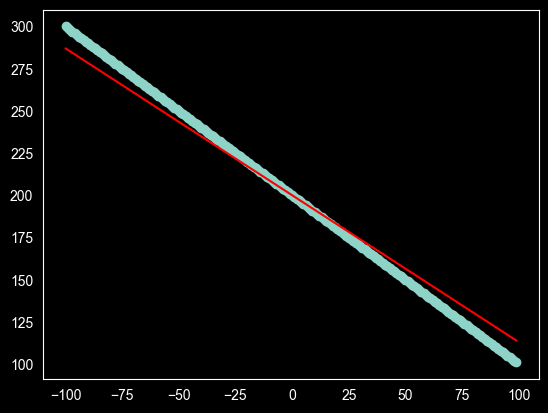

In [25]:
# Solve for Data 4
solve_by_svd(x4, y4)

Slope : -0.86548425   y-Intercept : 200.12225788   MSE : 91.5598   R2 : 0.9726


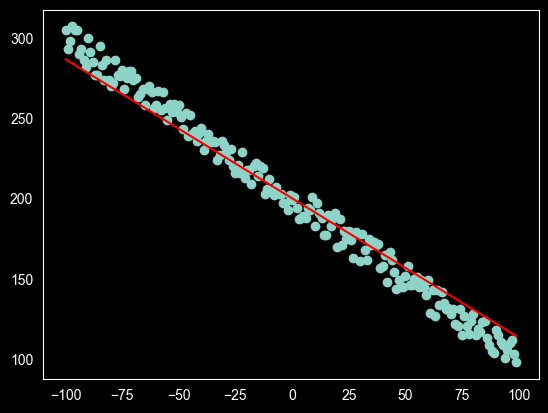

In [26]:
# Solve for Data 5
solve_by_svd(x5, y5)

Slope : -0.87024327   y-Intercept : 202.27487837   MSE : 829.4445   R2 : 0.7982


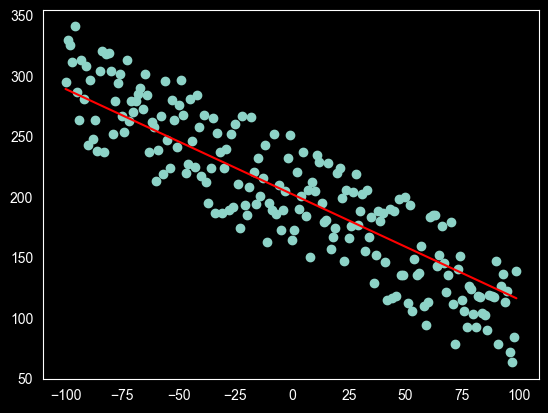

In [27]:
# Solve for Data 6
solve_by_svd(x6, y6)

Slope : -3.45033001   y-Intercept : 142.219835   MSE : 1340154.6364   R2 : 0.0371


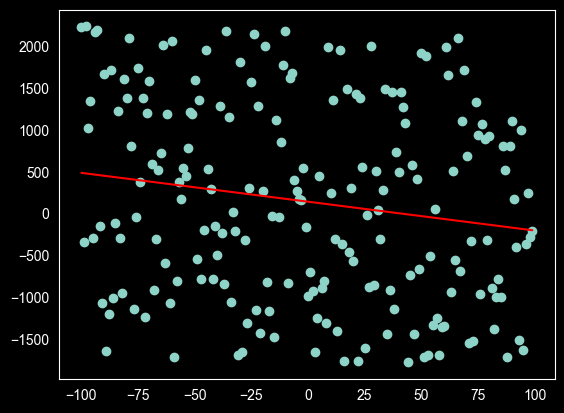

In [28]:
# Solve for Data 7
solve_by_svd(x7, y7)

### Solve by Grid Search

In [29]:
def solve_by_grid_search(x, y, alpha=1000):
    best_b0 = None
    best_b1 = None
    best_loss = float("inf")
    for b0 in range(-20, 2100):
        for b1 in range(-10, 11):
            b00 = b0 / 10
            b11 = b1 / 10
            predictions = []
            for xi in x:
                y_hat = b00 + b11 * xi
                predictions.append(y_hat)
            squared_errors = []
            for yi, y_hat in zip(y, predictions):
                squared_errors.append((yi - y_hat) ** 2)
            mse_ = sum(squared_errors) / len(y)
            rigid_penalty = alpha * b11**2
            loss = mse_ + rigid_penalty
            if loss < best_loss:
                best_loss = loss
                best_b0 = b00
                best_b1 = b11
    c = best_b0
    m = best_b1
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(
        f"Slope :", m,
        "  y-Intercept :", c,
        "  MSE :", MSE,
        "  R2 :", R2,
        "  Lasso Loss :", best_loss
    )
    plot(x, y, m, c)

Slope : 0.8   y-Intercept : -0.1   MSE : 133.33   R2 : 0.96   Lasso Loss : 773.33


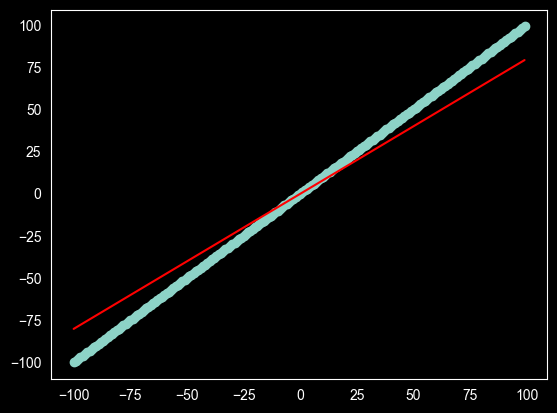

In [30]:
# Solve for Data 1
solve_by_grid_search(x1, y1)

Slope : 0.8   y-Intercept : 1.0   MSE : 164.553   R2 : 0.9507   Lasso Loss : 804.5530000000001


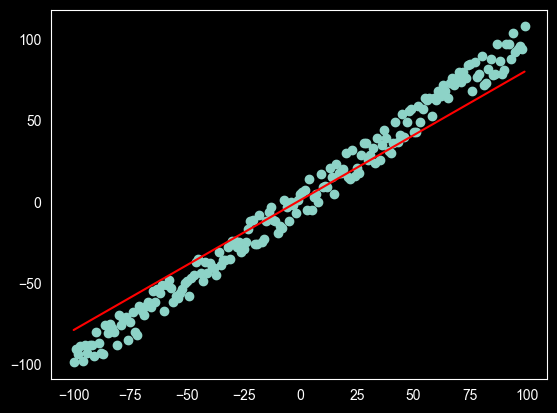

In [31]:
# Solve for Data 2
solve_by_grid_search(x2, y2)

Slope : 0.8   y-Intercept : 1.1   MSE : 1080.448   R2 : 0.7666   Lasso Loss : 1720.4480000000008


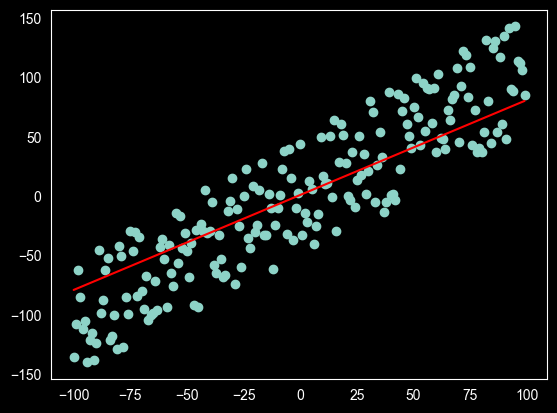

In [32]:
# Solve for Data 3
solve_by_grid_search(x3, y3)

Slope : -0.8   y-Intercept : 200.1   MSE : 133.33   R2 : 0.96   Lasso Loss : 773.33


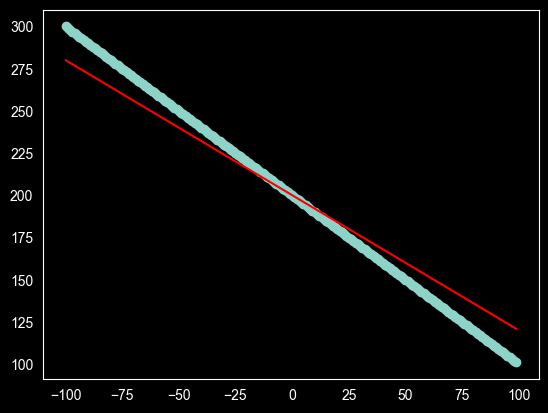

In [33]:
# Solve for Data 4
solve_by_grid_search(x4, y4)

Slope : -0.8   y-Intercept : 200.2   MSE : 162.531   R2 : 0.9513   Lasso Loss : 802.531


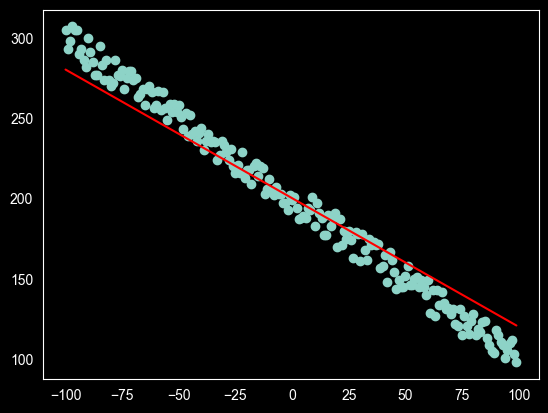

In [34]:
# Solve for Data 5
solve_by_grid_search(x5, y5)

Slope : -0.8   y-Intercept : 202.3   MSE : 907.02   R2 : 0.7794   Lasso Loss : 1547.0200000000004


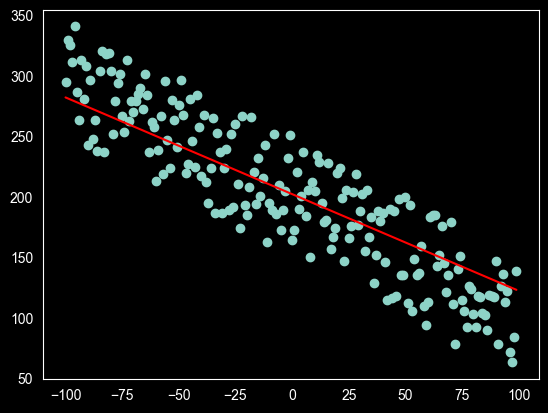

In [35]:
# Solve for Data 6
solve_by_grid_search(x6, y6)

In [ ]:
# Solve for Data 7
solve_by_grid_search(x7, y7)

### Solve by Gradient Descent

In [ ]:
def solve_by_grad_descent(x, y, n_epochs=300, eta=0.1, lmbda=1):
    x_scaled = (x - x.mean()) / x.std()
    y_scaled = (y - y.mean()) / y.std()
    x_b = np.array([[1, i] for i in x_scaled])
    theta = np.array([0, 0]).reshape(-1, 1)
    m = len(x_b)
    y_scaled = y_scaled.reshape(-1, 1)
    for epoch in range(n_epochs):
        gradients = 2 / m * x_b.T @ (x_b @ theta - y_scaled)
        ridge_gradient = 2 * lmbda * theta
        ridge_gradient[0] = 0
        gradients += ridge_gradient
        theta = theta - eta * gradients
    c_scaled = theta[0][0]
    m_scaled = theta[1][0]
    m = m_scaled * y.std() / x.std()
    c = (c_scaled * y.std() + y.mean() - m * x.mean())
    y_pred = predict(x, m, c)
    MSE = mse(y, y_pred)
    R2 = r2(y, y_pred)
    print(
        f"Slope : {round(m, 4)}"
        f"  y-Intercept : {round(c, 4)}"
        f"  MSE : {MSE}"
        f"  R2 : {R2}"
    )
    plot(x, y, m, c)

In [ ]:
# Solve for Data 1
solve_by_grad_descent(x1, y1)

In [ ]:
# Solve for Data 2
solve_by_grad_descent(x2, y2)

In [ ]:
# Solve for Data 3
solve_by_grad_descent(x3, y3)

In [ ]:
# Solve for Data 4
solve_by_grad_descent(x4, y4)

In [ ]:
# Solve for Data 5
solve_by_grad_descent(x5, y5)

In [ ]:
# Solve for Data 6
solve_by_grad_descent(x6, y6)

In [ ]:
# Solve for Data 7
solve_by_grad_descent(x7, y7)

### Solve by SkLearn

In [ ]:
from sklearn.linear_model import Ridge

def get_model(X, y):
    model = Ridge(alpha=300000)
    model.fit(X, y)
    return model.intercept_, model.coef_, model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import add_dummy_feature

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    MSE = mean_squared_error(y, y_pred)
    R2 = r2_score(y, y_pred)
    print(f"Slope :", m, "  y-Intercept :", round(c, 4), "  MSE :", MSE, "  R2 :", R2)
    plot(x, y, m, c)

In [ ]:
# Solve for Data 1
solve_by_sklearn(x1, y1)

In [ ]:
# Solve for Data 2
solve_by_sklearn(x2, y2)

In [ ]:
# Solve for Data 3
solve_by_sklearn(x3, y3)

In [ ]:
# Solve for Data 4
solve_by_sklearn(x4, y4)

In [ ]:
# Solve for Data 5
solve_by_sklearn(x5, y5)

In [ ]:
# Solve for Data 6
solve_by_sklearn(x6, y6)

In [ ]:
# Solve for Data 7
solve_by_sklearn(x7, y7)